---
title: Generate Styled Figures for ou_cox_timing_PM Blog Post
jupyter: python3
---

This notebook regenerates all figures for the blog post with styling that matches the website CSS.

## Setup

In [1]:
import numpy as np
from numpy import log, sqrt, exp
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
import sys
from pathlib import Path

# Import website styling module
sys.path.insert(0, str(Path.cwd()))
from plot_style import (
    COLORS, FONT_SIZES, setup_matplotlib_style,
    create_styled_figure, style_legend, format_datetime_axis,
    save_styled_figure
)

print("Styling module imported successfully")

# Define estimation functions (used in Figures 3 and 4)
from scipy.optimize import minimize

def neg_ll(theta, t, price, Delta, T, resolve_time):
    mu = theta[0]
    sigma = exp(theta[1])
    kappa = exp(theta[2])
    if resolve_time is None:
        resolve_time = T
    ll = 0
    for tk, price_k, price_kp1 in zip(t[:-1], price[:-1], price[1:]):
        if tk >= resolve_time:
            break
        tau = T - tk
        V = sigma**2 / (2 * kappa**3) * (2*kappa*tau + 4*exp(-kappa*tau) -exp(-2*kappa*tau) - 3)
        L1 = kappa / np.expm1(-kappa * tau)
        L2 = mu * tau - V / 2
        mean = price_k + price_k * Delta * (mu + L1*(log(price_k) + L2))
        std = price_k * sigma * sqrt(Delta) / kappa * abs(np.expm1(-kappa * tau))
        ll += -np.log(std) - (price_kp1 - mean)**2 / (2*std**2)
    return -ll

def neg_ll_fix_kappa(theta, kappa, t, price, Delta, T, resolve_time):
    mu = theta[0]
    sigma = exp(theta[1])
    if resolve_time is None:
        resolve_time = T
    ll = 0
    for tk, price_k, price_kp1 in zip(t[:-1], price[:-1], price[1:]):
        if tk >= resolve_time:
            break
        tau = T - tk
        V = sigma**2 / (2 * kappa**3) * (2*kappa*tau + 4*exp(-kappa*tau) -exp(-2*kappa*tau) - 3)
        L1 = kappa / np.expm1(-kappa * tau)
        L2 = mu * tau - V / 2
        mean = price_k + price_k * Delta * (mu + L1*(log(price_k) + L2))
        std = price_k * sigma * sqrt(Delta) / kappa * abs(np.expm1(-kappa * tau))
        ll += -np.log(std) - (price_kp1 - mean)**2 / (2*std**2)
    return -ll

def initializer(grid_size, kappa_min, kappa_max, t, price, Delta, T, resolve_time):
    kappa_grid = np.exp(np.linspace(np.log(kappa_min), np.log(kappa_max), grid_size))
    best_val = np.inf
    best_theta = None
    for kappa0 in kappa_grid:
        res = minimize(neg_ll_fix_kappa, [1, np.log(0.2)],
                       args=(kappa0, t, price, Delta, T, resolve_time), method="BFGS")
        if res.fun < best_val:
            best_val = res.fun
            best_theta = [res.x[0], np.exp(res.x[1]), kappa0]
    return best_theta, best_val

print("Estimation functions defined")

Styling module imported successfully
Estimation functions defined


## Figure 1: Trump 2024 Election Price History

Loaded 307 data points from Trump 2024 data


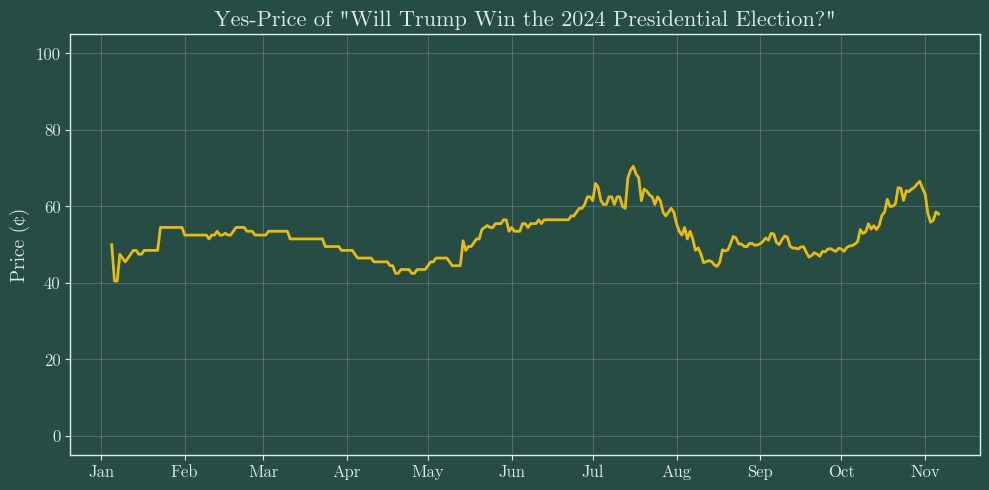

Figure 1 saved: trump2024daily.svg (307 data points)


In [2]:
# Load Trump data
trump_data = pd.read_csv('trump_2024_daily_040125.csv', skiprows=1,
                         names=['date', 'timestamp', 'price'])
trump_data['date'] = pd.to_datetime(trump_data['date'], format='%m-%d-%Y %H:%M')

n_trump = len(trump_data)
print(f"Loaded {n_trump} data points from Trump 2024 data")

# Create styled figure
fig, ax = create_styled_figure(figsize=(10, 5))

# Plot the data with golden yellow color
ax.plot(trump_data['date'], trump_data['price']*100, color=COLORS['primary'], linewidth=2)

# Set title and labels
ax.set_title('Yes-Price of "Will Trump Win the 2024 Presidential Election?"', 
             fontsize=FONT_SIZES['title'])
ax.set_ylabel('Price (¢)', fontsize=FONT_SIZES['label'])
ax.set_ylim(-5, 105)

# Format x-axis with 3-letter month names
format_datetime_axis(ax)

# Adjust layout and save
plt.tight_layout()
save_styled_figure(fig, 'trump2024daily.svg')
plt.show()
print(f"Figure 1 saved: trump2024daily.svg ({n_trump} data points)")

## Figure 2: Khamenei Price History

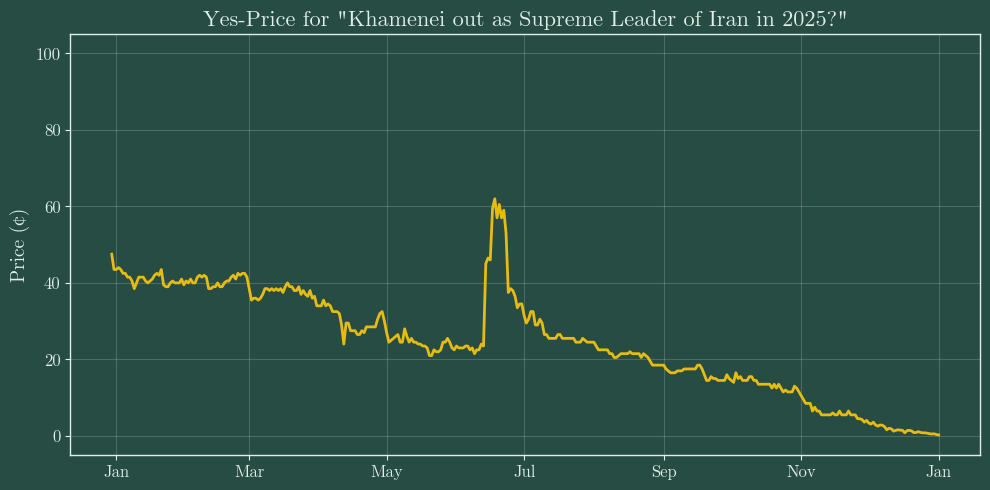

Figure 2 saved: khameiniOut2025.svg (368 data points)


In [3]:
# Load data
data = pd.read_csv('khamenei-out-as-supreme-leader-of-iran-in-2025-daily.csv', 
                   names=['date', 'timestamp', 'yes_price'], skiprows=1)
data['no_price'] = 1 - data['yes_price']
data['date'] = pd.to_datetime(data['date'])
# normalize timestamp to [0, 1] - required for intensity reconstruction
data['timestamp'] -= data['timestamp'].iloc[0]
data['timestamp'] /= data['timestamp'].iloc[-1]

n = len(data)

# Create styled figure
fig, ax = create_styled_figure(figsize=(10, 5))

# Plot the data with golden yellow color
ax.plot(data['date'], data['yes_price']*100, color=COLORS['primary'], linewidth=2)

# Set title and labels
ax.set_title('Yes-Price for "Khamenei out as Supreme Leader of Iran in 2025?"', 
             fontsize=FONT_SIZES['title'])
ax.set_ylabel('Price (¢)', fontsize=FONT_SIZES['label'])
ax.set_ylim(-5, 105)

# Format x-axis with 3-letter month names
format_datetime_axis(ax)

# Adjust layout and save
plt.tight_layout()
save_styled_figure(fig, 'khameiniOut2025.svg')
plt.show()
print(f"Figure 2 saved: khameiniOut2025.svg ({n} data points)")

## Next Figures

Figures 3-8 will be added here as we style them one by one.

### Figure 3: Reconstructed Intensity and Volatility

Use the parameter estimates from the blog post (Section "Looking at a Real Market"):

In [4]:
# Constants for the real data
Delta = 0.002725  # the timedelta corresponding to daily prices
T = 1
T0 = 0
resolve_time = 1

# Parameter estimates from blog post
mu_hat = 0.69
sigma_hat = 2.85
kappa_hat = 3.61

print(f"Using blog post parameter estimates: μ={mu_hat:.2f}, σ={sigma_hat:.2f}, κ={kappa_hat:.2f}")

Using blog post parameter estimates: μ=0.69, σ=2.85, κ=3.61


Now reconstruct intensity and volatility:

In [5]:
# Reconstruct intensity
intensity_hat = np.zeros(n)
intensity_hat[-1] = np.nan
for k, (tk, price_k) in enumerate(zip(data['timestamp'][:-1], data['no_price'][:-1])):
    tau = T - tk
    V = sigma_hat**2 / (2 * kappa_hat**3) * (2*kappa_hat*tau + 4*exp(-kappa_hat*tau) -exp(-2*kappa_hat*tau) - 3)
    L1 = kappa_hat / np.expm1(-kappa_hat*tau)
    L2 = mu_hat * tau - V / 2
    intensity_hat[k] = mu_hat + L1 * (log(price_k) + L2)
data['intensity'] = intensity_hat

# Reconstruct volatility
vol_hat = np.zeros(n)
for k, (tk, price_k) in enumerate(zip(data['timestamp'], data['no_price'])):
    tau = T - tk
    vol_hat[k] = abs(price_k * sigma_hat / kappa_hat * np.expm1(-kappa_hat*tau))
vol_realized = np.sqrt(np.pi / 2) * abs(np.diff(data['no_price'])) / sqrt(Delta)
data['vol_reconstructed'] = vol_hat
data['vol_realized'] = np.append(vol_realized, np.nan)

print("Intensity and volatility reconstructed successfully")

Intensity and volatility reconstructed successfully


Now create Figure 3:

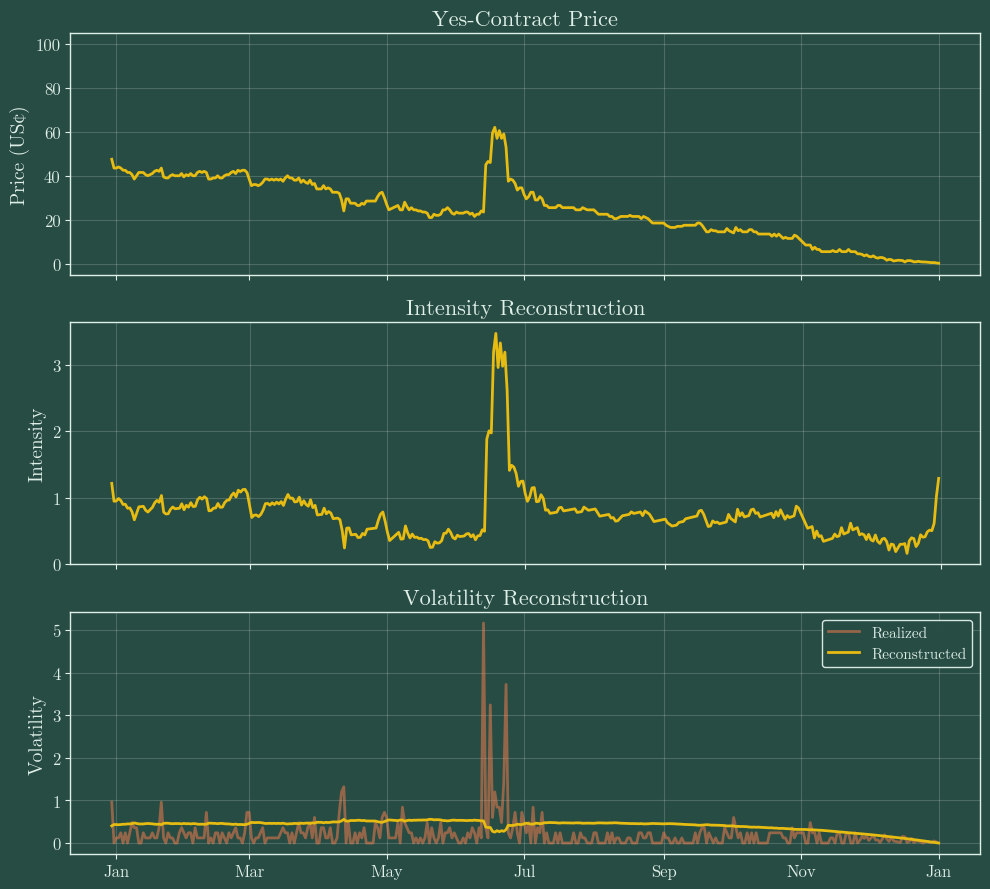

Figure 3 saved: reconstruction.svg


In [6]:
# Create 3-subplot styled figure
fig, (ax0, ax1, ax2) = create_styled_figure(nrows=3, ncols=1, figsize=(10, 9))

# --- Top: yes price ---
ax0.plot(data['date'], data['yes_price'] * 100, color=COLORS['primary'], linewidth=2)
ax0.set_title('Yes-Contract Price', fontsize=FONT_SIZES['title'])
ax0.set_ylabel('Price (US¢)', fontsize=FONT_SIZES['label'])
ax0.set_ylim(-5, 105)
# Hide x-axis labels for top plots
ax0.tick_params(axis='x', labelbottom=False)

# --- Middle: intensity ---
ax1.plot(data['date'], data['intensity'], color=COLORS['primary'], linewidth=2)
ax1.set_title('Intensity Reconstruction', fontsize=FONT_SIZES['title'])
ax1.set_ylabel('Intensity', fontsize=FONT_SIZES['label'])
# Hide x-axis labels for middle plot
ax1.tick_params(axis='x', labelbottom=False)

# --- Bottom: volatility ---
ax2.plot(data['date'], data['vol_realized'], color=COLORS['secondary'], 
         label='Realized', alpha=0.5, linewidth=2)
ax2.plot(data['date'], data['vol_reconstructed'], color=COLORS['primary'], 
         label='Reconstructed', linewidth=2)
ax2.set_title('Volatility Reconstruction', fontsize=FONT_SIZES['title'])
ax2.set_ylabel('Volatility', fontsize=FONT_SIZES['label'])
style_legend(ax2, loc='upper right')

# Format x-axis with month names only on bottom subplot
format_datetime_axis(ax2)

# Adjust layout and save
plt.tight_layout()
save_styled_figure(fig, 'reconstruction.svg')
plt.show()
print("Figure 3 saved: reconstruction.svg")

### Figure 4: Monte Carlo Forecasts

First, define the simulation function:

In [7]:
rng = np.random.default_rng(42)

def simulate_timing_market(mu, sigma, kappa, price_init, n, T0=0, T=1):
    Delta = (T - T0) / n

    price = np.zeros(n)
    price[0] = 1 - price_init  # price_init should be a yes-price
    intensity = np.zeros(n)
    intensity[-1] = np.nan
    resolve_time = None
    for k in range(0, n-1):
        tk = Delta*k + T0
        tau = T - tk
        V = sigma**2 / (2 * kappa**3) * (2*kappa*tau + 4*exp(-kappa*tau) -exp(-2*kappa*tau) - 3)
        L1 = kappa / (exp(-kappa*tau) - 1)
        L2 = mu * tau - V / 2
    
        # check if market resolves in [t_k, t_k+1]
        prob_res = 1 - price[k]**(-Delta * L1) * exp(-Delta * (mu + L1 * L2))
        if rng.random() < prob_res:
            resolve_time = tk
            break
    
        while True:
            drift = price[k] * Delta*(mu + L1*(log(price[k]) + L2))
            diffusion = price[k] * sigma / kappa * sqrt(Delta) * (exp(-kappa*tau) - 1) * rng.normal()
            proposed_price = price[k] + drift + diffusion
            # accept proposed_price if it does not imply a negative intensity
            # else throw it away and try again
            if proposed_price <= exp(-(mu / L1 + L2)):
                price[k+1] = price[k] + drift + diffusion
                intensity[k] = mu + L1 * (log(price[k]) + L2)
                break
            else:
                pass

    t = np.linspace(T0, T, num=n)
    return t, price, intensity, resolve_time, Delta

Now re-estimate parameters using only partial data (to avoid data leakage as mentioned in the blog):

In [8]:
# Forecast parameters
i0 = 250  # starting index (around September)
t0 = data['timestamp'].iloc[i0]
price0 = data['yes_price'].iloc[i0]
num_mc_sims = 1000
horizon = 0.3  # 30% of remaining time
horizon_index = i0 + int(horizon/Delta) + 1

print(f"Re-estimating parameters using data up to index {i0}...")

# Grid search parameters
grid_size = 10
kappa_min, kappa_max = 1e-1, 5

# Re-estimate parameters on partial data
theta0_partial, _ = initializer(grid_size, kappa_min, kappa_max, 
                                 data['timestamp'].iloc[:i0], 
                                 data['no_price'].iloc[:i0], 
                                 Delta, T, resolve_time)

res_partial = minimize(
    neg_ll,
    theta0_partial,
    args=(data['timestamp'].iloc[:i0], data['no_price'].iloc[:i0], Delta, T, resolve_time),
    method="BFGS",
    options={"disp": False, "gtol": 1e-6}
)

mu_hat_partial, log_sigma_hat_partial, log_kappa_hat_partial = res_partial.x
sigma_hat_partial = np.exp(log_sigma_hat_partial)
kappa_hat_partial = np.exp(log_kappa_hat_partial)

print(f"Partial data parameter estimates: μ={mu_hat_partial:.2f}, σ={sigma_hat_partial:.2f}, κ={kappa_hat_partial:.2f}")
print(f"Full data parameter estimates: μ={mu_hat:.2f}, σ={sigma_hat:.2f}, κ={kappa_hat:.2f}")
print(f"\nCreating {num_mc_sims} Monte Carlo simulations from index {i0} (t={t0:.2f})")
print(f"Forecast horizon: {horizon:.2f} time units")

# Run simulations
t_MC = np.zeros([num_mc_sims, n-i0])
price_MC = np.zeros([num_mc_sims, n-i0])
intensity_MC = np.zeros([num_mc_sims, n-i0])
vol_MC = np.zeros([num_mc_sims, n-i0])
resolve_time_MC = np.zeros(num_mc_sims)
Delta_MC = np.zeros(num_mc_sims)

for i in range(num_mc_sims):
    while True:
        t_sample, price_sample, intensity_sample, resolve_time_sample, Delta_sample = simulate_timing_market(
            mu_hat_partial, sigma_hat_partial, kappa_hat_partial, price0, n-i0, T0=t0, T=T
        )
        if resolve_time_sample is None: 
            resolve_time_sample = np.inf
        if resolve_time_sample >= t0+horizon: 
            break
        
    for k, (tk, price_k) in enumerate(zip(t_sample, price_sample)):
        tau = T - tk
        vol_MC[i, k] = abs(price_k * sigma_hat_partial / kappa_hat_partial * np.expm1(-kappa_hat_partial*tau))
    
    t_MC[i, :] = t_sample
    price_MC[i, :] = price_sample
    intensity_MC[i, :] = intensity_sample
    resolve_time_MC[i] = resolve_time_sample
    Delta_MC[i] = Delta_sample

# Calculate statistics
price_mean = np.mean(price_MC, axis=0)
price_low, price_high = np.quantile(price_MC, [0.025, 0.975], axis=0)
intensity_mean = np.mean(intensity_MC, axis=0)
intensity_low, intensity_high = np.quantile(intensity_MC, [0.025, 0.975], axis=0)
vol_mean = np.mean(vol_MC, axis=0)
vol_low, vol_high = np.quantile(vol_MC, [0.025, 0.975], axis=0)

print("Monte Carlo simulations complete")

# Create time array for plotting
t = np.linspace(0, 1, num=n)

# Calculate intensity and volatility reconstructions using PARTIAL parameters
intensity_partial = np.zeros(n)
intensity_partial[-1] = np.nan
vol_partial = np.zeros(n)

for k, (tk, price_k) in enumerate(zip(data['timestamp'][:-1], data['no_price'][:-1])):
    tau = T - tk
    V = sigma_hat_partial**2 / (2 * kappa_hat_partial**3) * (2*kappa_hat_partial*tau + 4*exp(-kappa_hat_partial*tau) -exp(-2*kappa_hat_partial*tau) - 3)
    L1 = kappa_hat_partial / np.expm1(-kappa_hat_partial*tau)
    L2 = mu_hat_partial * tau - V / 2
    intensity_partial[k] = mu_hat_partial + L1 * (log(price_k) + L2)

for k, (tk, price_k) in enumerate(zip(data['timestamp'], data['no_price'])):
    tau = T - tk
    vol_partial[k] = abs(price_k * sigma_hat_partial / kappa_hat_partial * np.expm1(-kappa_hat_partial*tau))

print("Partial parameter reconstructions calculated")

# Create date arrays for plotting (convert normalized time to dates)
# Find date corresponding to forecast start (i0)
from datetime import datetime, timedelta
start_date = data['date'].iloc[0]
end_date = data['date'].iloc[-1]
total_days = (end_date - start_date).days

# Convert normalized time to dates for MC simulations
t_dates = [start_date + timedelta(days=idx * total_days / (n-1)) for idx in range(n)]
t_mc_dates = [start_date + timedelta(days=(i0 + idx) * total_days / (n-1)) for idx in range(n-i0)]

print(f"Date range: {start_date.date()} to {end_date.date()}")
print(f"Forecast from {t_dates[i0].date()} to {t_dates[min(horizon_index, len(t_dates)-1)].date()}")

Re-estimating parameters using data up to index 250...
Partial data parameter estimates: μ=0.83, σ=20.60, κ=27.81
Full data parameter estimates: μ=0.69, σ=2.85, κ=3.61

Creating 1000 Monte Carlo simulations from index 250 (t=0.68)
Forecast horizon: 0.30 time units
Monte Carlo simulations complete
Partial parameter reconstructions calculated
Date range: 2024-12-30 to 2026-01-01
Forecast from 2025-09-06 to 2025-12-26


Now create the styled figure:

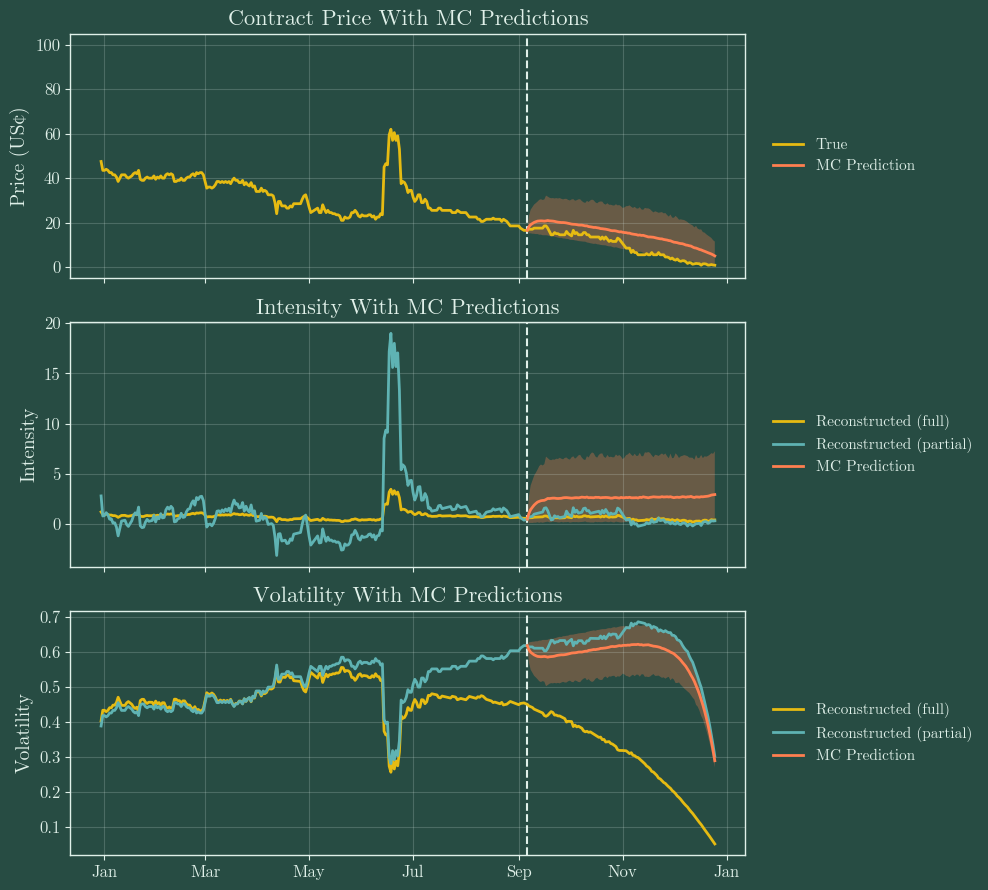

Figure 4 saved: forecasts.svg (1000 simulations)


In [9]:
# Create 3-subplot figure with different height ratios
fig, (ax1, ax2, ax3) = create_styled_figure(nrows=3, ncols=1, figsize=(10, 9))

# --- Top: Contract Price ---
ax1.axvline(t_dates[i0], color=COLORS['text'], linestyle='--', linewidth=1.5)
ax1.plot(t_dates[:horizon_index], data['yes_price'][:horizon_index] * 100, 
         color=COLORS['primary'], linewidth=2, label='True')
ax1.plot(t_mc_dates[:horizon_index-i0], (1-price_mean[:horizon_index-i0])*100, 
         color=COLORS['secondary'], linewidth=2, label='MC Prediction')
ax1.fill_between(t_mc_dates[:horizon_index-i0], 
                 100*(1-price_high[:horizon_index-i0]), 
                 100*(1-price_low[:horizon_index-i0]), 
                 color=COLORS['secondary'], alpha=0.3, edgecolor=None)
ax1.set_title('Contract Price With MC Predictions', fontsize=FONT_SIZES['title'])
ax1.set_ylabel('Price (US¢)', fontsize=FONT_SIZES['label'])
ax1.set_ylim(-5, 105)
ax1.tick_params(axis='x', labelbottom=False)
style_legend(ax1, loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)

# --- Middle: Intensity ---
ax2.axvline(t_dates[i0], color=COLORS['text'], linestyle='--', linewidth=1.5)
ax2.plot(data['date'][:horizon_index], data['intensity'][:horizon_index], 
         color=COLORS['primary'], linewidth=2, label='Reconstructed (full)')
ax2.plot(data['date'][:horizon_index], intensity_partial[:horizon_index], 
         color=COLORS['tertiary'], linewidth=2, label='Reconstructed (partial)')
ax2.plot(t_mc_dates[:horizon_index-i0], intensity_mean[:horizon_index-i0], 
         color=COLORS['secondary'], linewidth=2, label='MC Prediction')
ax2.fill_between(t_mc_dates[:horizon_index-i0], 
                 intensity_high[:horizon_index-i0], 
                 intensity_low[:horizon_index-i0], 
                 color=COLORS['secondary'], alpha=0.3, edgecolor=None)
ax2.set_title('Intensity With MC Predictions', fontsize=FONT_SIZES['title'])
ax2.set_ylabel('Intensity', fontsize=FONT_SIZES['label'])
ax2.tick_params(axis='x', labelbottom=False)
style_legend(ax2, loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)

# --- Bottom: Volatility ---
ax3.axvline(t_dates[i0], color=COLORS['text'], linestyle='--', linewidth=1.5)
ax3.plot(data['date'][:horizon_index], data['vol_reconstructed'][:horizon_index], 
         color=COLORS['primary'], linewidth=2, label='Reconstructed (full)')
ax3.plot(data['date'][:horizon_index], vol_partial[:horizon_index], 
         color=COLORS['tertiary'], linewidth=2, label='Reconstructed (partial)')
ax3.plot(t_mc_dates[:horizon_index-i0], vol_mean[:horizon_index-i0], 
         color=COLORS['secondary'], linewidth=2, label='MC Prediction')
ax3.fill_between(t_mc_dates[:horizon_index-i0], 
                 vol_high[:horizon_index-i0], 
                 vol_low[:horizon_index-i0], 
                 color=COLORS['secondary'], alpha=0.3, edgecolor=None)
ax3.set_title('Volatility With MC Predictions', fontsize=FONT_SIZES['title'])
ax3.set_ylabel('Volatility', fontsize=FONT_SIZES['label'])
format_datetime_axis(ax3)
style_legend(ax3, loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)

# Adjust layout and save
plt.tight_layout()
save_styled_figure(fig, 'forecasts.svg')
plt.show()
print(f"Figure 4 saved: forecasts.svg ({num_mc_sims} simulations)")

### Figures 5a/b: Probability Estimates

#### Figure 5a: Simulated Data (Well-Calibrated)

Use simulated data to show well-calibrated probability estimates:

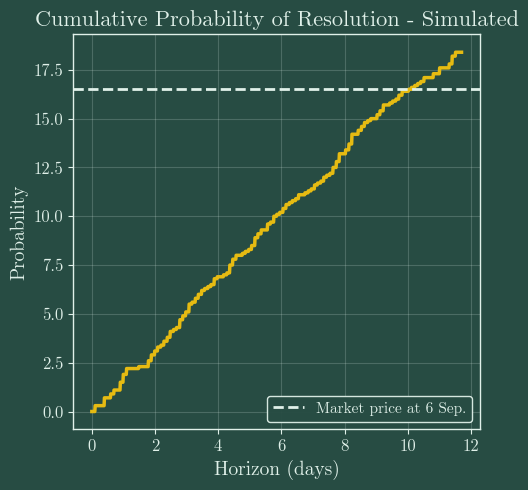

Figure 5a saved: prob_sim.svg (simulated data)


In [10]:
# Use the same forecast parameters as in the blog post
i0 = 250
t0 = data['timestamp'].iloc[i0]
price0 = data['yes_price'].iloc[i0]
num_mc_sims = 1000

# Run simulations with simulated data parameters (μ=1, σ=0.5, κ=0.5)
mu_sim = 1
sigma_sim = 0.5
kappa_sim = 0.5

res_times = np.zeros(num_mc_sims)
for k in range(num_mc_sims):
    _, _, _, res_t, _ = simulate_timing_market(mu_sim, sigma_sim, kappa_sim, price0, n-i0, T0=t0, T=T)
    if res_t is None:
        res_times[k] = np.inf
    else:
        res_times[k] = res_t

# Calculate probability grid
horizon_grid = np.linspace(0, T-t0, num=1000)
prob_grid = [100*np.mean(res_times <= t0 + horizon) for horizon in horizon_grid]

# Convert to days for x-axis
horizon_days = horizon_grid / Delta / 10  # Convert normalized time to days

# Create figure
fig, ax = create_styled_figure(figsize=(5, 5))

ax.plot(horizon_days, prob_grid, color=COLORS['primary'], linewidth=2.5)
ax.axhline(price0*100, color=COLORS['text'], linestyle='--', linewidth=2, 
           label='Market price at 6 Sep.')
ax.set_xlabel('Horizon (days)', fontsize=FONT_SIZES['label'])
ax.set_ylabel('Probability', fontsize=FONT_SIZES['label'])
ax.set_title('Cumulative Probability of Resolution - Simulated', fontsize=FONT_SIZES['title'])
style_legend(ax, loc='lower right')

plt.tight_layout()
save_styled_figure(fig, 'prob_sim.svg')
plt.show()
print("Figure 5a saved: prob_sim.svg (simulated data)")

#### Figure 5b: Real Data (Mis-calibrated)

Use real data with re-estimated partial parameters:

Re-estimating parameters on partial data...
Real data parameters: μ=0.83, σ=20.60, κ=27.81


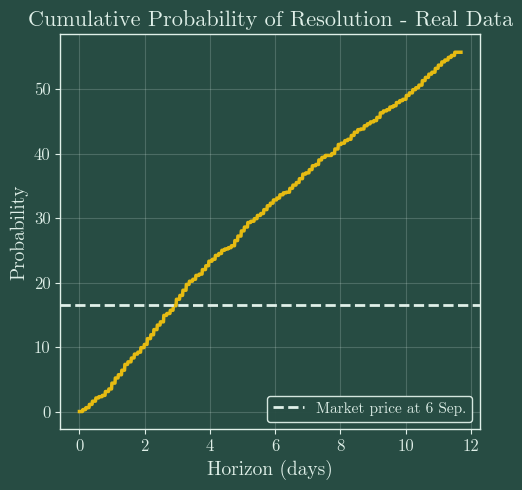

Figure 5b saved: prob_real.svg (real data)


In [11]:
# Re-estimate parameters on partial data (already done in Figure 4, but redo for clarity)
print("Re-estimating parameters on partial data...")

theta0_partial, _ = initializer(grid_size, kappa_min, kappa_max, 
                                 data['timestamp'].iloc[:i0], 
                                 data['no_price'].iloc[:i0], 
                                 Delta, T, resolve_time)

res_partial = minimize(
    neg_ll,
    theta0_partial,
    args=(data['timestamp'].iloc[:i0], data['no_price'].iloc[:i0], Delta, T, resolve_time),
    method="BFGS",
    options={"disp": False, "gtol": 1e-6}
)

mu_hat_real, log_sigma_hat_real, log_kappa_hat_real = res_partial.x
sigma_hat_real = np.exp(log_sigma_hat_real)
kappa_hat_real = np.exp(log_kappa_hat_real)

print(f"Real data parameters: μ={mu_hat_real:.2f}, σ={sigma_hat_real:.2f}, κ={kappa_hat_real:.2f}")

# Run simulations
res_times_real = np.zeros(num_mc_sims)
for k in range(num_mc_sims):
    _, _, _, res_t, _ = simulate_timing_market(mu_hat_real, sigma_hat_real, kappa_hat_real, 
                                               price0, n-i0, T0=t0, T=T)
    if res_t is None:
        res_times_real[k] = np.inf
    else:
        res_times_real[k] = res_t

# Calculate probability grid
prob_grid_real = [100*np.mean(res_times_real <= t0 + horizon) for horizon in horizon_grid]

# Create figure
fig, ax = create_styled_figure(figsize=(5, 5))

ax.plot(horizon_days, prob_grid_real, color=COLORS['primary'], linewidth=2.5)
ax.axhline(price0*100, color=COLORS['text'], linestyle='--', linewidth=2, 
           label='Market price at 6 Sep.')
ax.set_xlabel('Horizon (days)', fontsize=FONT_SIZES['label'])
ax.set_ylabel('Probability', fontsize=FONT_SIZES['label'])
ax.set_title('Cumulative Probability of Resolution - Real Data', fontsize=FONT_SIZES['title'])
style_legend(ax, loc='lower right')

plt.tight_layout()
save_styled_figure(fig, 'prob_real.svg')
plt.show()
print("Figure 5b saved: prob_real.svg (real data)")

### Figure 6: Diagnostics (Standardized Residuals)

Calculate standardized residuals and create diagnostic plots:

In [12]:
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf

# Use full data parameters for in-sample validation
mu_hat = 0.69
sigma_hat = 2.85
kappa_hat = 3.61

# Calculate standardized residuals
returns_norm = np.zeros(n-1)
for k in range(0, n-1):
    tk = Delta*k + T0
    tau = T - tk
    V = sigma_hat**2 / (2 * kappa_hat**3) * (2*kappa_hat*tau + 4*exp(-kappa_hat*tau) - exp(-2*kappa_hat*tau) - 3)
    L1 = kappa_hat / (exp(-kappa_hat*tau) - 1)
    L2 = mu_hat * tau - V / 2

    rk = data['no_price'][k+1] - data['no_price'][k]
    mean = data['no_price'][k] * Delta * (mu_hat + L1 * (log(data['no_price'][k]) + L2))
    std = abs(data['no_price'][k] * sigma_hat / kappa_hat * sqrt(Delta) * np.expm1(-kappa_hat * tau))
    rk_norm = (rk - mean) / std

    returns_norm[k] = rk_norm

print(f"Standardized residuals calculated: {len(returns_norm)} values")

Standardized residuals calculated: 367 values


Now create the diagnostic figure with website styling:

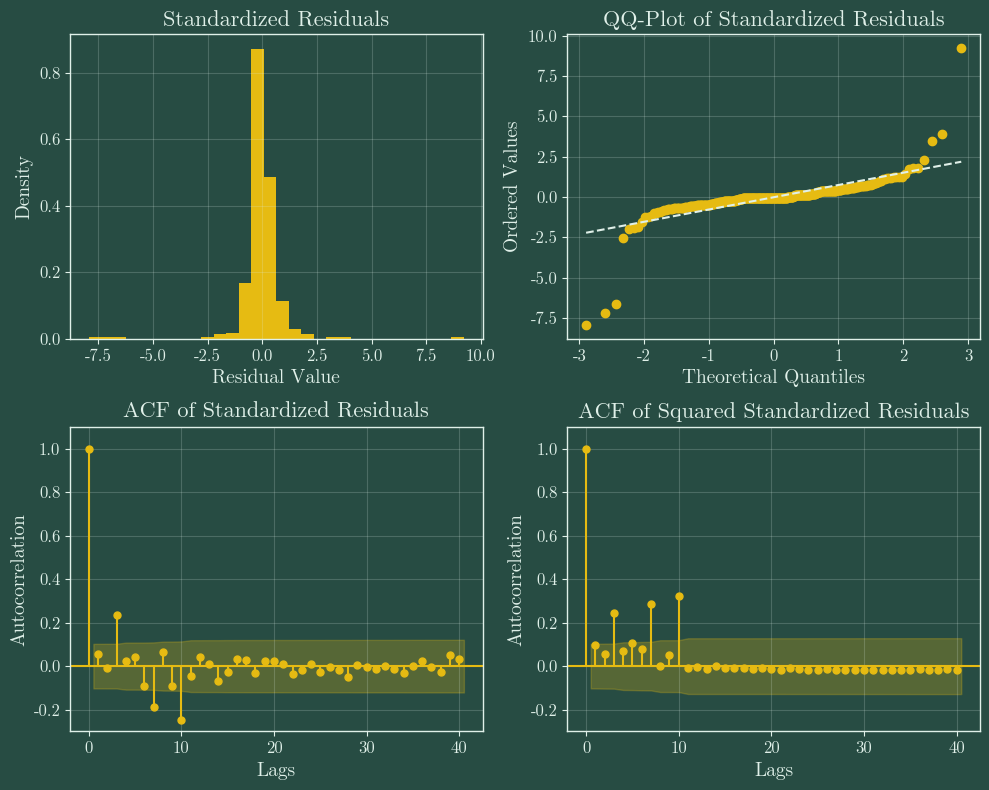

Figure 6 saved: diagnostics.svg


In [13]:
# Create 2x2 subplot figure
fig, axes = create_styled_figure(nrows=2, ncols=2, figsize=(10, 8))
axes = axes.flatten()

# Histogram
axes[0].hist(returns_norm, bins=30, density=True, color=COLORS['primary'], edgecolor='none')
axes[0].set_title('Standardized Residuals', fontsize=FONT_SIZES['title'])
axes[0].set_xlabel('Residual Value', fontsize=FONT_SIZES['label'])
axes[0].set_ylabel('Density', fontsize=FONT_SIZES['label'])

# QQ-plot
stats.probplot(returns_norm, dist="norm", plot=axes[1])
axes[1].set_title('QQ-Plot of Standardized Residuals', fontsize=FONT_SIZES['title'])
axes[1].set_xlabel('Theoretical Quantiles', fontsize=FONT_SIZES['label'])
axes[1].set_ylabel('Ordered Values', fontsize=FONT_SIZES['label'])

# Style the QQ plot - points in primary color, ideal line white dashed
lines = axes[1].lines
if len(lines) >= 2:
    # First line is usually the data points
    lines[0].set_color(COLORS['primary'])
    lines[0].set_markerfacecolor(COLORS['primary'])
    # Second line is the ideal/reference line
    lines[1].set_color(COLORS['text'])
    lines[1].set_linestyle('--')
    lines[1].set_linewidth(1.5)

# ACF of residuals
nlags = min(40, len(returns_norm) - 1)
plot_acf(returns_norm, lags=nlags, ax=axes[2], color=COLORS['primary'])
axes[2].set_title('ACF of Standardized Residuals', fontsize=FONT_SIZES['title'])
axes[2].set_xlabel('Lags', fontsize=FONT_SIZES['label'])
axes[2].set_ylabel('Autocorrelation', fontsize=FONT_SIZES['label'])
axes[2].set_ylim(-0.3, 1.1)

# Style all ACF lines to be primary color
for line in axes[2].lines:
    line.set_color(COLORS['primary'])
for collection in axes[2].collections:
    collection.set_facecolor(COLORS['primary'])
    collection.set_edgecolor(COLORS['primary'])

# ACF of squared residuals
plot_acf(returns_norm**2, lags=nlags, ax=axes[3], color=COLORS['primary'])
axes[3].set_title('ACF of Squared Standardized Residuals', fontsize=FONT_SIZES['title'])
axes[3].set_xlabel('Lags', fontsize=FONT_SIZES['label'])
axes[3].set_ylabel('Autocorrelation', fontsize=FONT_SIZES['label'])
axes[3].set_ylim(-0.3, 1.1)

# Style all ACF lines to be primary color
for line in axes[3].lines:
    line.set_color(COLORS['primary'])
for collection in axes[3].collections:
    collection.set_facecolor(COLORS['primary'])
    collection.set_edgecolor(COLORS['primary'])

plt.tight_layout()
save_styled_figure(fig, 'diagnostics.svg')
plt.show()
print("Figure 6 saved: diagnostics.svg")

### Figure 7: Prediction Interval Coverage

Calculate coverage of one-step-ahead prediction intervals:

In [14]:
from scipy import stats

# Use full data parameters
mu_hat = 0.69
sigma_hat = 2.85
kappa_hat = 3.61

def CI_coverage(level):
    alpha = 1 - level
    covered_count = 0
    tested_count = 0
    for k in range(0, n-1):
        tk = Delta*k + T0
        tau = T - tk
        V = sigma_hat**2 / (2 * kappa_hat**3) * (2*kappa_hat*tau + 4*exp(-kappa_hat*tau) - exp(-2*kappa_hat*tau) - 3)
        L1 = kappa_hat / (exp(-kappa_hat*tau) - 1)
        L2 = mu_hat * tau - V / 2

        if tk >= resolve_time:
            break

        mean = data['no_price'][k] + data['no_price'][k] * Delta * (mu_hat + L1 * (log(data['no_price'][k]) + L2))
        std = abs(data['no_price'][k] * sigma_hat / kappa_hat * sqrt(Delta) * np.expm1(-kappa_hat * tau))
        z = stats.norm.ppf(1 - alpha/2)

        tested_count += 1
        if data['no_price'][k+1] > mean - z*std and data['no_price'][k+1] < mean + z*std:
            covered_count += 1
    return covered_count / tested_count

# Calculate coverage for different confidence levels
levels = np.linspace(0.01, 0.99, 50)
coverages = [CI_coverage(level) for level in levels]

print(f"Coverage calculated for {len(levels)} confidence levels")

Coverage calculated for 50 confidence levels


Create the coverage plot:

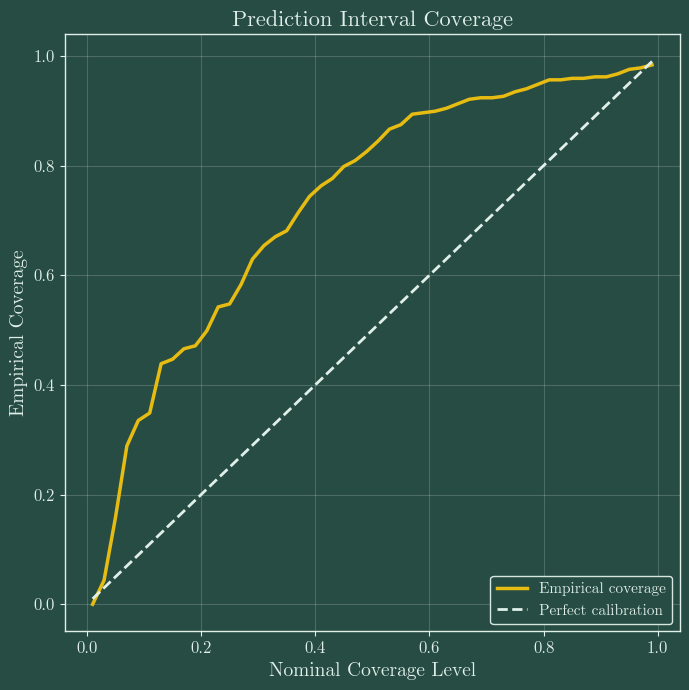

Figure 7 saved: ci_coverage.svg


In [15]:
# Create figure
fig, ax = create_styled_figure(figsize=(7, 7))

ax.plot(levels, coverages, color=COLORS['primary'], linewidth=2.5, label='Empirical coverage')
ax.plot(levels, levels, color=COLORS['text'], linestyle='--', linewidth=2, 
        label='Perfect calibration')
ax.set_xlabel('Nominal Coverage Level', fontsize=FONT_SIZES['label'])
ax.set_ylabel('Empirical Coverage', fontsize=FONT_SIZES['label'])
ax.set_title('Prediction Interval Coverage', fontsize=FONT_SIZES['title'])
style_legend(ax, loc='lower right')

plt.tight_layout()
save_styled_figure(fig, 'ci_coverage.svg')
plt.show()
print("Figure 7 saved: ci_coverage.svg")